# Tracking 120 Years of Women at the Summer Olympics
**JOURN 124 — Final Project · Analysis notebook**
*By Roy Kapoor*

This notebook documents every step of the analysis behind the data story:
loading the data, cleaning it, and producing the two charts. Every code cell
is commented so the work is fully reproducible.

**Dataset:** *120 years of Olympic history: athletes and results* — 271,116 rows,
one row per athlete per event, Athens 1896 → Rio 2016.
**Original source:** scraped from [Sports-Reference.com / Olympedia] and published to
[Kaggle](https://www.kaggle.com/heesoo37/120-years-of-olympic-history-athletes-and-results) by Randi H. Griffin.

## 1. Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# The CSV uses the literal string "NA" for missing values, so tell pandas to treat it as null.
df = pd.read_csv("athlete_events.csv", na_values=["NA"])

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## 2. Get to know the data (and its gaps)
Before analyzing, I check how complete each column is. This matters journalistically:
columns that are mostly empty can't support strong claims.

In [2]:
# Percentage of values missing in each column
(df.isna().mean() * 100).round(1)

ID         0.0
Name       0.0
Sex        0.0
Age        3.5
Height    22.2
Weight    23.2
Team       0.0
NOC        0.0
Games      0.0
Year       0.0
Season     0.0
City       0.0
Sport      0.0
Event      0.0
Medal     85.3
dtype: float64

**What I found:** `Medal` is ~85% empty — but that is *correct*, because most athletes
don't win a medal (a blank just means "no medal"). `Height` and `Weight` are missing for
~22–23% of rows, especially in early Games, so I avoid building the story on those columns.
`Sex`, `Year`, `Sport` and `ID` are 100% complete — and those are the columns my story relies on.

In [3]:
# Basic shape of the data
print("Years covered:", df.Year.min(), "to", df.Year.max())
print("Seasons:", df.Season.unique())
print("Distinct athletes:", df.ID.nunique())
print("Sex breakdown (rows):", df.Sex.value_counts().to_dict())

Years covered: 1896 to 2016
Seasons: ['Summer' 'Winter']
Distinct athletes: 135571
Sex breakdown (rows): {'M': 196594, 'F': 74522}


## 3. Clean / reshape for the question
**Key data-cleaning decision:** one row = one athlete in one *event*. An athlete who swims
three events appears three times. To count *people* (not event entries) I count **distinct
athlete IDs** per Games. I also focus on the **Summer Games**, which have the long continuous
history; the Winter Games started in 1924 and would muddy a single time line.

In [4]:
# Keep only Summer Games
summer = df[df.Season == "Summer"].copy()

# For each Summer Games year, count distinct women and distinct total athletes
def counts(group):
    total = group.ID.nunique()
    women = group[group.Sex == "F"].ID.nunique()
    return pd.Series({"women": women, "total_athletes": total})

by_year = summer.groupby("Year").apply(counts, include_groups=False)
by_year["pct_women"] = (by_year.women / by_year.total_athletes * 100).round(1)
by_year

,women,total_athletes,pct_women
Year,,,
1896,0,176,0.0
1900,23,1224,1.9
1904,6,650,0.9
1906,6,841,0.7
1908,44,2024,2.2
1912,53,2409,2.2
1920,78,2676,2.9
1924,156,3256,4.8
1928,312,3247,9.6


**Finding #1:** Women were **0%** of athletes at the first modern Games (Athens 1896),
first appeared in 1900 (1.9%), and climbed steadily to **45.0%** at Rio 2016 — close to,
but still short of, parity.

## 4. Chart 1 — the long climb (line chart)

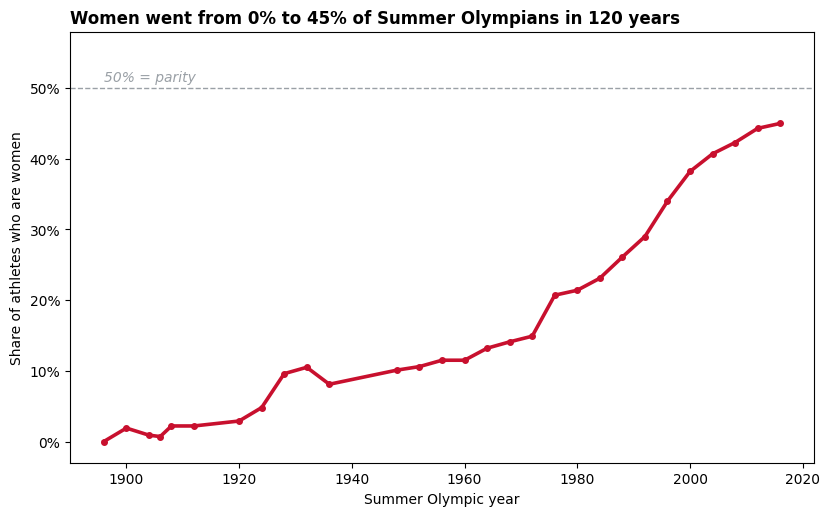

In [5]:
fig, ax = plt.subplots(figsize=(9.6, 5.6))
ax.plot(by_year.index, by_year.pct_women, color="#C8102E", lw=2.6)
ax.scatter(by_year.index, by_year.pct_women, color="#C8102E", s=16)
ax.axhline(50, color="#9aa0a6", ls="--", lw=1)            # parity reference line
ax.text(1896, 51, "50% = parity", color="#9aa0a6", style="italic")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylim(-3, 58)
ax.set_xlabel("Summer Olympic year")
ax.set_ylabel("Share of athletes who are women")
ax.set_title("Women went from 0% to 45% of Summer Olympians in 120 years",
             fontweight="bold", loc="left")
plt.show()

## 5. Does the average tell the whole story? (Finding #2)
A single 45% number could hide big differences between sports. To check, I break the most
recent Games (Rio 2016) down by sport, again counting distinct athletes. I keep sports with
at least 50 athletes so small events don't produce noisy percentages.

In [6]:
rio = summer[summer.Year == 2016]

def sport_share(group):
    total = group.ID.nunique()
    women = group[group.Sex == "F"].ID.nunique()
    return pd.Series({"athletes": total, "pct_women": round(women/total*100, 1)})

by_sport = rio.groupby("Sport").apply(sport_share, include_groups=False)
by_sport = by_sport[by_sport.athletes >= 50].sort_values("pct_women")
by_sport

,athletes,pct_women
Sport,,
Boxing,283.0,12.7
Wrestling,346.0,32.4
Canoeing,330.0,33.9
Cycling,513.0,37.4
Equestrianism,200.0,37.5
Shooting,390.0,38.7
Judo,389.0,39.1
Rowing,546.0,39.4
Water Polo,258.0,40.3


**Finding #2:** The 45% average masks a wide spread. **Boxing** was just **12.7%** women
(women's boxing was only added in 2012). Most sports cluster right around 50%, and two —
**rhythmic gymnastics** and **synchronized swimming** — are **100%** women because they have
no men's event at all. The aggregate hides both the lagging sports and the women-only ones.

## 6. Chart 2 — the spread across sports (bar chart)

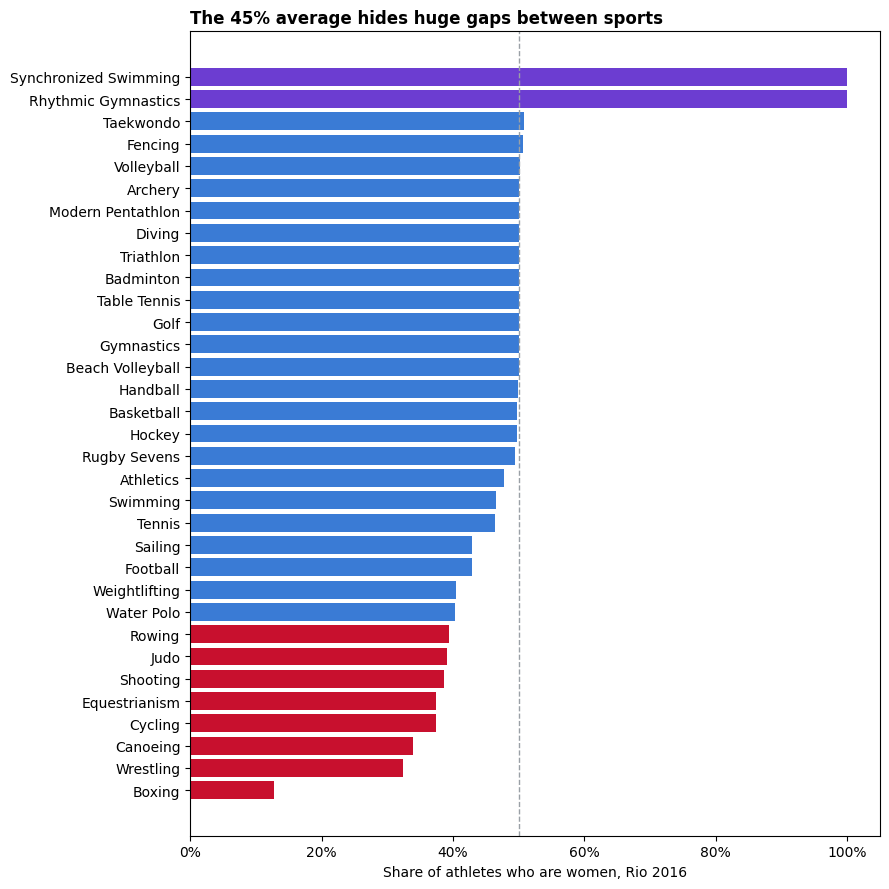

In [7]:
fig, ax = plt.subplots(figsize=(9, 9))
colors = ["#C8102E" if p < 40 else ("#6c3dd1" if p >= 99.9 else "#3a7bd5")
          for p in by_sport.pct_women]
ax.barh(by_sport.index, by_sport.pct_women, color=colors)
ax.axvline(50, color="#9aa0a6", ls="--", lw=1)           # parity reference line
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Share of athletes who are women, Rio 2016")
ax.set_title("The 45% average hides huge gaps between sports",
             fontweight="bold", loc="left")
plt.tight_layout()
plt.show()

## 7. One more check: who was excluded the longest?
A quick look at when a few countries *first* sent a woman to the Summer Games shows the
trend wasn't only about sport — it was also about national policy.

In [8]:
for noc in ["KSA", "QAT", "BRU"]:   # Saudi Arabia, Qatar, Brunei
    first = summer[(summer.NOC == noc) & (summer.Sex == "F")].Year.min()
    print(noc, "first sent a woman to the Summer Games in:", int(first))

KSA first sent a woman to the Summer Games in: 2012
QAT first sent a woman to the Summer Games in: 2012
BRU first sent a woman to the Summer Games in: 2012


**Finding #3:** Saudi Arabia, Qatar and Brunei did not send a single female athlete until
**2012** — the first Games at which every participating country included at least one woman.

---
### Summary of findings
1. Female share of Summer Olympians rose from **0% (1896) to 45% (2016)**.
2. That average hides a wide range by sport — from **12.7%** (boxing) to **100%** (women-only sports).
3. Full national inclusion is recent: some countries sent their first woman only in **2012**.

See the project `README.md` for the full write-up, methods, limitations, and ethical discussion.